# Gaussian Processes Summer School

## Part 5: Non-stationary Kernels

<a href="https://www.uc3m.es/"><img src="./uc3m.png" alt="Universidad Carlos III de Madrid" width="520"></a>

**Author:** [Pablo M. Olmos](https://olmos-pm.github.io/)  
**Email:** [pamartin@ing.uc3m.es](mailto:pamartin@ing.uc3m.es)

---

### A one-dimensional Gaussian process with input-dependent smoothness

We construct a collection of signals that are smooth on the left of the input domain and progressively rougher on the right. The change is produced by a valid non-stationary covariance function, not by stitching together unrelated processes.

## Learning goals

1. Distinguish stationarity from non-stationarity in a covariance function.
2. Use the Gibbs kernel to encode a lengthscale that varies with the input.
3. Sample a database of signals from the resulting GP.
4. Diagnose non-stationarity from sample paths, the covariance matrix, and local covariance slices.
5. Quantify the error made by RBF, spectral-mixture, and implicit **stationary** kernels.

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

seed = 7
rng = np.random.default_rng(seed)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. From stationary to non-stationary covariance

A stationary kernel has the form

$$k(x,x')=k(x-x').$$

Consequently, every pair of inputs separated by the same lag has the same covariance, regardless of where that pair lies. For example, an RBF kernel uses one global lengthscale $\ell$:

$$k_{\mathrm{RBF}}(x,x')=\sigma_f^2\exp\left[-\frac{(x-x')^2}{2\ell^2}\right].$$

To allow the local smoothness to change with position, we replace the global lengthscale with a positive function $\ell(x)$. A valid covariance that implements this idea is the one-dimensional **Gibbs kernel**:

$$
k_{\mathrm{Gibbs}}(x,x')=\sigma_f^2
\sqrt{\frac{2\ell(x)\ell(x')}{\ell(x)^2+\ell(x')^2}}
\exp\left[-\frac{(x-x')^2}{\ell(x)^2+\ell(x')^2}\right].
$$

It reduces to the RBF kernel when $\ell(x)$ is constant. Otherwise it depends on the absolute locations $x$ and $x'$, so it is non-stationary. Its diagonal remains $k(x,x)=\sigma_f^2$: only smoothness changes here, while marginal signal variance stays constant.

### Intuition for the square-root term

The factor

$$c(x,x')=\sqrt{\frac{2\ell(x)\ell(x')}{\ell(x)^2+\ell(x')^2}}$$

measures how compatible the two **local notions of smoothness** are. Imagine that each input carries a Gaussian smoothing window whose width is $\ell(x)$. By the arithmetic--geometric mean inequality,

$$0<c(x,x')\leq 1.$$

If $\ell(x)=\ell(x')$, then $c(x,x')=1$: the two locations agree about the local scale and no penalty is needed. If one lengthscale is much larger than the other, then $c(x,x')$ approaches zero: a very smooth region and a very rough region share less covariance than distance alone would suggest. At $x=x'$, both lengthscales are necessarily equal, so the factor is exactly one and preserves $k(x,x)=\sigma_f^2$. This term is also part of what makes the input-dependent construction a valid positive-definite kernel; simply inserting a varying lengthscale into an RBF exponent would not generally be sufficient.

### Design an input-dependent lengthscale

We use a decreasing logistic transition,

$$\ell(x)=\ell_{\min}+(\ell_{\max}-\ell_{\min})\,\frac{1}{1+\exp(sx)},$$

with $\ell_{\max}=0.80$, $\ell_{\min}=0.08$, and $s=2$. The GP is therefore smooth on the left, changes regime around zero, and is rough on the right.

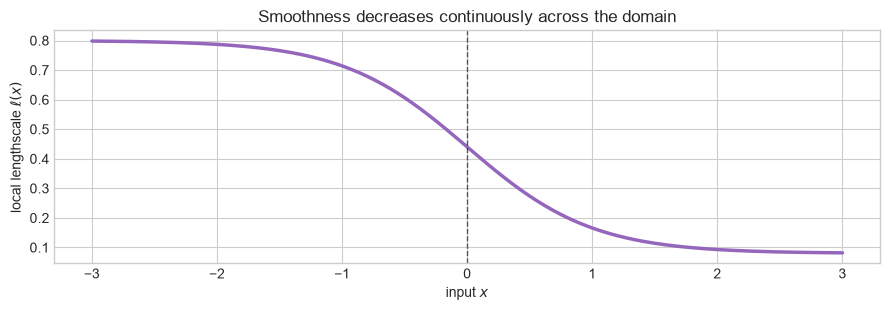

In [50]:
n_points = 200
x = np.linspace(-3.0, 3.0, n_points)

ell_min = 0.08
ell_max = 0.80
transition_steepness = 2.0
signal_std = 1.0
noise_std = 0.03

def lengthscale_function(x):
    return ell_min + (ell_max - ell_min) / (1.0 + np.exp(transition_steepness * x))

local_lengthscale = lengthscale_function(x)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(x, local_lengthscale, linewidth=2.5, color="tab:purple")
ax.axvline(0.0, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax.set(xlabel=r"input $x$", ylabel=r"local lengthscale $\ell(x)$",
       title="Smoothness decreases continuously across the domain")
fig.tight_layout()
plt.show()

### Build the covariance and sample the dataset

Every curve below is an independent draw from the same GP,

$$f_i\sim\mathcal{GP}(0,k_{\mathrm{Gibbs}}),\qquad y_i(x)=f_i(x)+\epsilon_i(x),$$

where $\epsilon_i(x)\sim\mathcal N(0,\sigma_n^2)$. Thus the location of the smooth-to-rough transition is shared by the entire population; the particular shape of each curve is random.

In [51]:
def gibbs_kernel(x1, x2, lengthscale_fn, outputscale=1.0):
    x1 = np.asarray(x1, dtype=float)[:, None]
    x2 = np.asarray(x2, dtype=float)[None, :]
    ell1 = lengthscale_fn(x1)
    ell2 = lengthscale_fn(x2)
    ell_squared_sum = ell1**2 + ell2**2
    normalization = np.sqrt(2.0 * ell1 * ell2 / ell_squared_sum)
    return outputscale**2 * normalization * np.exp(-(x1 - x2)**2 / ell_squared_sum)

K = gibbs_kernel(x, x, lengthscale_function, outputscale=signal_std)
K = 0.5 * (K + K.T)  # remove floating-point asymmetry

n_signals = 300
jitter = 1e-9
L = np.linalg.cholesky(K + jitter * np.eye(n_points))
latent_signals = rng.standard_normal((n_signals, n_points)) @ L.T
observed_signals = latent_signals + noise_std * rng.standard_normal(latent_signals.shape)

dataset_summary = pd.DataFrame({
    "quantity": ["signals", "points per signal", "input interval",
                 "min / max lengthscale", "signal std", "noise std"],
    "value": [n_signals, n_points, "[-3, 3]",
              f"{local_lengthscale.min():.3f} / {local_lengthscale.max():.3f}",
              signal_std, noise_std],
})
display(dataset_summary)
print("latent_signals shape:", latent_signals.shape)
print("observed_signals shape:", observed_signals.shape)

,quantity,value
0,signals,300
1,points per signal,200
2,input interval,"[-3, 3]"
3,min / max lengthscale,0.082 / 0.798
4,signal std,1.0
5,noise std,0.03


latent_signals shape: (300, 200)
observed_signals shape: (300, 200)


### Sample paths

The large lengthscale on the left suppresses rapid variation. On the right, nearby inputs decorrelate much faster and the paths develop fine-scale structure. The faint dots show noisy observations and the solid lines show their latent GP functions.

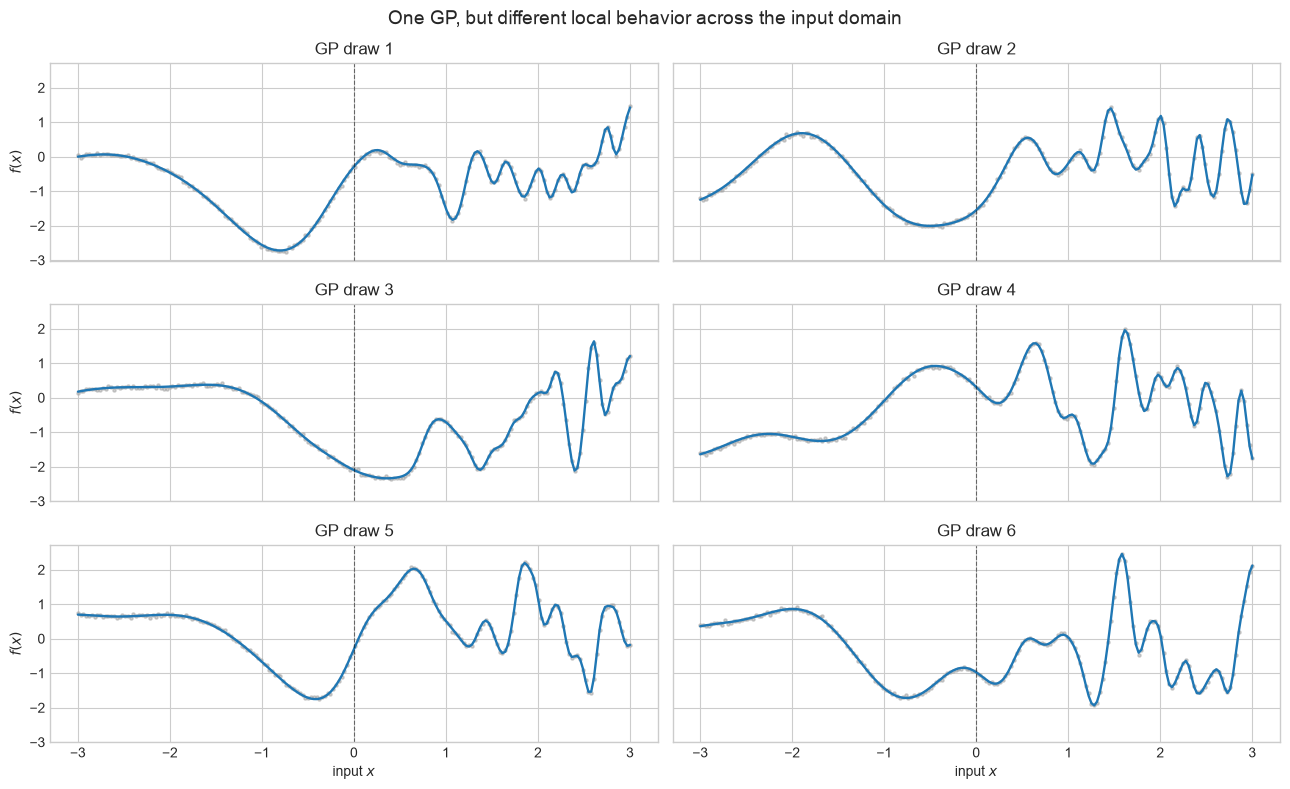

In [52]:
fig, axes = plt.subplots(3, 2, figsize=(13, 8), sharex=True, sharey=True)
for signal_index, ax in enumerate(axes.flat):
    ax.scatter(x, observed_signals[signal_index], s=5, color="0.65", alpha=0.55)
    ax.plot(x, latent_signals[signal_index], linewidth=1.7, color="tab:blue")
    ax.axvline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_title(f"GP draw {signal_index + 1}")
for ax in axes[-1]:
    ax.set_xlabel(r"input $x$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$f(x)$")
fig.suptitle("One GP, but different local behavior across the input domain", fontsize=14)
fig.tight_layout()
plt.show()

### The equal-lag test

Stationarity would require $k(x_0,x_0+\tau)$ to be identical for every anchor location $x_0$. We evaluate it around three anchors. The covariance decays slowly at $x_0=-2$, moderately at $x_0=0$, and rapidly at $x_0=2$. This directly disproves stationarity.

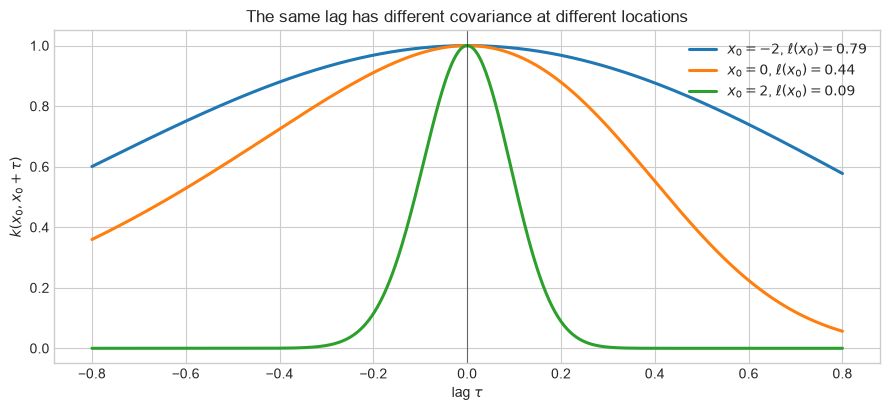

In [53]:
anchors = [-2.0, 0.0, 2.0]
tau = np.linspace(-0.8, 0.8, 500)

fig, ax = plt.subplots(figsize=(9, 4.2))
for anchor in anchors:
    covariance_slice = gibbs_kernel(
        np.array([anchor]), anchor + tau, lengthscale_function, signal_std
    ).ravel()
    ax.plot(tau, covariance_slice, linewidth=2.2,
            label=rf"$x_0={anchor:g}$, $\ell(x_0)={lengthscale_function(anchor):.2f}$")
ax.axvline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax.set(xlabel=r"lag $\tau$", ylabel=rf"$k(x_0,x_0+\tau)$",
       title="The same lag has different covariance at different locations")
ax.legend()
fig.tight_layout()
plt.show()

### See non-stationarity in the covariance matrix

For a stationary RBF kernel sampled on a regular grid, the covariance matrix has a constant-width band along its diagonal. Here that band is wide in the upper-left region and narrow in the lower-right region: correlation persists over larger distances on the left than on the right.

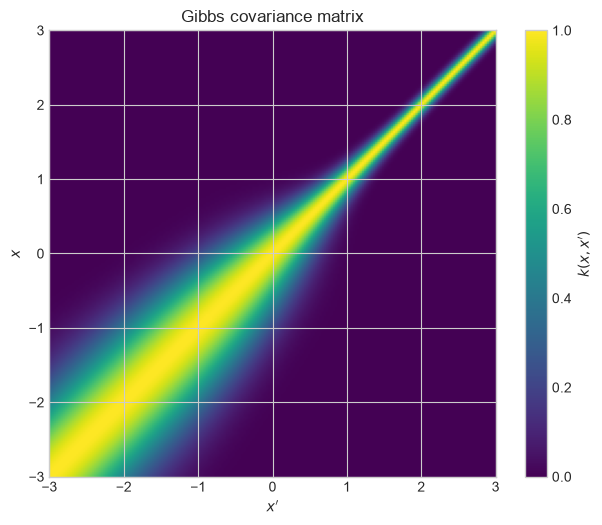

In [54]:
fig, ax = plt.subplots(figsize=(6.5, 5.3))
image = ax.imshow(K, origin="lower", extent=[x.min(), x.max(), x.min(), x.max()],
                  cmap="viridis", vmin=0.0, vmax=signal_std**2, aspect="equal")
ax.set(xlabel=r"$x'$", ylabel=r"$x$", title="Gibbs covariance matrix")
fig.colorbar(image, ax=ax, label=r"$k(x,x')$")
fig.tight_layout()
plt.show()

## 7. How well can stationary spectral kernels fit these data?

We now deliberately misspecify the model class. All three competitors are stationary, so each must use the same covariance at a given lag everywhere on the domain:

- **A. RBF RFF:** a zero-centered Gaussian spectral density, represented with random Fourier features.
- **B. Three locally periodic components:** a weighted sum of three symmetric Gaussian spectral bands.
- **C. Implicit spectral kernel:** a neural network transforms Gaussian noise into a flexible frequency distribution.

Models B and C have much more flexible stationary spectra than model A, but none can make its spectrum depend on $x$. This experiment separates **spectral flexibility** from the ability to represent **non-stationarity**.

In [55]:
import gpytorch
import torch

from train_gp_models import (
    as_gp_tensors,
    build_rff_gp,
    build_symmetric_spectral_mixture_rff_gp,
    learned_hyperparameters,
    learned_spectral_mixture_parameters,
    mean_negative_log_likelihood,
    train_shared_gp,
)
from train_implicit_spectral_gp import (
    build_implicit_spectral_gp,
    train_implicit_spectral_gp,
)

# CPU is predictable for the small exact linear algebra used here.
# Change this to torch.device("cuda") if desired.
if torch.cuda.is_available():
    model_device = torch.device("cuda")
elif torch.backends.mps.is_available():
    model_device = torch.device("mps")
else:
    model_device = torch.device("cpu")
model_dtype = torch.float32  # required on MPS; also sufficient for this experiment
torch.manual_seed(seed)
print("GPyTorch:", gpytorch.__version__, "| device:", model_device, "| dtype:", model_dtype)

GPyTorch: 1.15.2 | device: mps | dtype: torch.float32


### Shared train/test split

We split by complete curves. The models learn one shared kernel from the training population and are evaluated on unseen GP realizations. To keep this teaching notebook quick to rerun, 120 curves are used for fitting and 60 for testing; both subsets come from the original population of 300.

In [56]:
split_rng = np.random.default_rng(seed + 100)
permutation = split_rng.permutation(n_signals)
fit_indices = permutation[:120]
test_indices = permutation[120:180]

fit_curves = observed_signals[fit_indices]
test_curves = observed_signals[test_indices]
train_x_tensor, fit_curves_tensor = as_gp_tensors(
    x, fit_curves, dtype=model_dtype, device=model_device
)
_, test_curves_tensor = as_gp_tensors(
    x, test_curves, dtype=model_dtype, device=model_device
)
print(f"fit curves: {len(fit_curves)} | test curves: {len(test_curves)}")

fit curves: 120 | test curves: 60


### Fit A: stationary RBF RFF kernel

The model learns a single global RBF lengthscale. We draw 240 frequencies and use their paired sine and cosine features, ensuring that the approximation depends only on $x-x'$.

In [57]:
num_rff_features = 300  # x2 frequencies, each producing sine and cosine features
rbf_model, rbf_likelihood = build_rff_gp(
    train_x_tensor,
    fit_curves_tensor,
    num_features=num_rff_features,
    seed=seed + 110,
    initial_lengthscale=0.25,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
)
rbf_losses = train_shared_gp(
    rbf_model, rbf_likelihood, train_x_tensor, fit_curves_tensor,
    num_steps=1000, learning_rate=0.04, print_every=100,
)

step    1/1000 | loss=42.2684 | ell=0.2413 | scale=1.0255 | noise=0.00094
step  100/1000 | loss=-0.5529 | ell=0.0682 | scale=1.5561 | noise=0.00255
step  200/1000 | loss=-0.5824 | ell=0.0654 | scale=1.0700 | noise=0.00247
step  300/1000 | loss=-0.5978 | ell=0.0633 | scale=0.8246 | noise=0.00232
step  400/1000 | loss=-0.6048 | ell=0.0630 | scale=0.7932 | noise=0.00215
step  500/1000 | loss=-0.6138 | ell=0.0613 | scale=0.7884 | noise=0.00199
step  600/1000 | loss=-0.6213 | ell=0.0610 | scale=0.7815 | noise=0.00182
step  700/1000 | loss=-0.6264 | ell=0.0608 | scale=0.7830 | noise=0.00168
step  800/1000 | loss=-0.6295 | ell=0.0607 | scale=0.7842 | noise=0.00158
step  900/1000 | loss=-0.6312 | ell=0.0605 | scale=0.7852 | noise=0.00150
step 1000/1000 | loss=-0.6322 | ell=0.0603 | scale=0.7856 | noise=0.00144


### Fit B: stationary mixture of three locally periodic kernels

Each component learns its spectral center, bandwidth, and mixture weight. We allocate 80 frequencies to each component, for the same total of 240 sampled frequencies used by the other two models. The initial bandwidths deliberately cover smooth, intermediate, and rough scales.

In [58]:
num_components = 3
lp_model, lp_likelihood = build_symmetric_spectral_mixture_rff_gp(
    train_x_tensor,
    fit_curves_tensor,
    initial_component_means=torch.tensor([0.1, 0.5, 2.0]),
    num_frequencies_per_component=100,
    spectral_variance=torch.tensor([1.5, 12.0, 100.0]),
    learn_spectral_variance=True,
    initial_weights=torch.full((num_components,), 1.0 / num_components),
    seed=seed + 120,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
)
lp_losses = train_shared_gp(
    lp_model, lp_likelihood, train_x_tensor, fit_curves_tensor,
    num_steps=1000, learning_rate=0.015, print_every=100,
)

step    1/1000 | loss=2.2359 | spectral_means=[0.101 0.494 1.987] | variances=[  1.512  11.985 100.015] | weights=[0.33 0.33 0.34] | noise=0.00091
step  100/1000 | loss=-0.0227 | spectral_means=[0.254 0.276 1.55 ] | variances=[  1.84   11.794 101.043] | weights=[0.123 0.121 0.757] | noise=0.00248
step  200/1000 | loss=-0.2072 | spectral_means=[0.254 0.231 1.553] | variances=[  1.481  11.715 101.632] | weights=[0.085 0.081 0.834] | noise=0.00394
step  300/1000 | loss=-0.2440 | spectral_means=[0.173 0.206 1.553] | variances=[  1.081  11.614 102.099] | weights=[0.071 0.065 0.863] | noise=0.00496
step  400/1000 | loss=-0.2532 | spectral_means=[0.513 0.19  1.556] | variances=[  0.752  11.526 102.535] | weights=[0.064 0.057 0.879] | noise=0.00549
step  500/1000 | loss=-0.2569 | spectral_means=[0.542 0.179 1.563] | variances=[  0.524  11.482 102.991] | weights=[0.06  0.051 0.889] | noise=0.00569
step  600/1000 | loss=-0.2600 | spectral_means=[0.602 0.173 1.571] | variances=[  0.361  11.492 10

### Fit C: stationary implicit spectral kernel

An MLP maps simple Gaussian noise to frequencies. This can learn a complicated multimodal spectrum without evaluating a spectral density. Paired sine/cosine features still produce a stationary kernel: neural flexibility changes the shape of $k(\tau)$, not its dependence on absolute position.

In [59]:
implicit_model, implicit_likelihood = build_implicit_spectral_gp(
    train_x_tensor,
    fit_curves_tensor,
    noise_dimension=8,
    num_frequencies=300,
    hidden_features=(32, 32),
    initial_frequency_scale=5.0,
    initial_outputscale=1.0,
    initial_noise=noise_std**2,
    seed=seed + 130,
)
implicit_history = train_implicit_spectral_gp(
    implicit_model, implicit_likelihood, train_x_tensor, fit_curves_tensor,
    num_steps=1000, learning_rate=0.004, frequency_penalty_weight=1e-5,
    resampling_seed=seed + 131, print_every=100,
)

step    1/1000 | objective=217.1436 | NLL=217.1436 | freq RMS=0.707 | noise=0.00090
step  100/1000 | objective=-0.6290 | NLL=-0.6312 | freq RMS=14.700 | noise=0.00100
step  200/1000 | objective=-0.6196 | NLL=-0.6215 | freq RMS=13.962 | noise=0.00102
step  300/1000 | objective=-0.6997 | NLL=-0.7016 | freq RMS=13.956 | noise=0.00105
step  400/1000 | objective=-0.7096 | NLL=-0.7114 | freq RMS=13.198 | noise=0.00107
step  500/1000 | objective=-0.6220 | NLL=-0.6235 | freq RMS=12.276 | noise=0.00109
step  600/1000 | objective=-0.7387 | NLL=-0.7404 | freq RMS=12.918 | noise=0.00112
step  700/1000 | objective=-0.7404 | NLL=-0.7421 | freq RMS=13.190 | noise=0.00113
step  800/1000 | objective=-0.6391 | NLL=-0.6417 | freq RMS=16.099 | noise=0.00115
step  900/1000 | objective=-0.7172 | NLL=-0.7191 | freq RMS=13.712 | noise=0.00117
step 1000/1000 | objective=-0.6607 | NLL=-0.6623 | freq RMS=12.938 | noise=0.00118


### Error metrics

Because the data-generating covariance is known, we can measure error directly rather than relying only on likelihood. For a learned signal covariance $\widehat K$, define

$$E_{\mathrm{rel}}=\frac{\|\widehat K-K_{\mathrm{Gibbs}}\|_F}{\|K_{\mathrm{Gibbs}}\|_F}.$$

We also report mean absolute covariance error, held-out negative log likelihood per observation, and relative errors within the left and right diagonal blocks. The block errors reveal which local regime each global stationary compromise fits best. Observation noise is included for test NLL but excluded from covariance error.

In [60]:
stationary_models = {
    "A. RBF RFF": (rbf_model, rbf_likelihood),
    "B. 3-component LP": (lp_model, lp_likelihood),
    "C. Implicit spectrum": (implicit_model, implicit_likelihood),
}

def learned_signal_covariance(model, x_tensor):
    model.eval()
    with torch.no_grad():
        return model.covar_module(x_tensor).to_dense().cpu().numpy()

def relative_frobenius(estimate, target):
    return np.linalg.norm(estimate - target, ord="fro") / np.linalg.norm(target, ord="fro")

left_block = np.ix_(x < -1.0, x < -1.0)
right_block = np.ix_(x > 1.0, x > 1.0)
learned_covariances = {}
comparison_rows = []

for name, (model, likelihood) in stationary_models.items():
    covariance = learned_signal_covariance(model, train_x_tensor)
    learned_covariances[name] = covariance
    comparison_rows.append({
        "model": name,
        "relative kernel error": relative_frobenius(covariance, K),
        "mean absolute error": np.mean(np.abs(covariance - K)),
        "left-block error": relative_frobenius(covariance[left_block], K[left_block]),
        "right-block error": relative_frobenius(covariance[right_block], K[right_block]),
        "test NLL / observation": mean_negative_log_likelihood(
            model, likelihood, train_x_tensor, test_curves_tensor
        ),
    })

comparison_table = pd.DataFrame(comparison_rows).set_index("model")
display(comparison_table.style.format(precision=4).set_caption(
    "Error of stationary models on non-stationary GP data"
))

,relative kernel error,mean absolute error,left-block error,right-block error,test NLL / observation
model,,,,,
A. RBF RFF,0.8762,0.1654,0.9050,0.4982,-0.6663
B. 3-component LP,1.1282,0.2534,0.8652,2.0753,-0.2757
C. Implicit spectrum,0.7791,0.1417,0.8135,0.5205,-0.7124


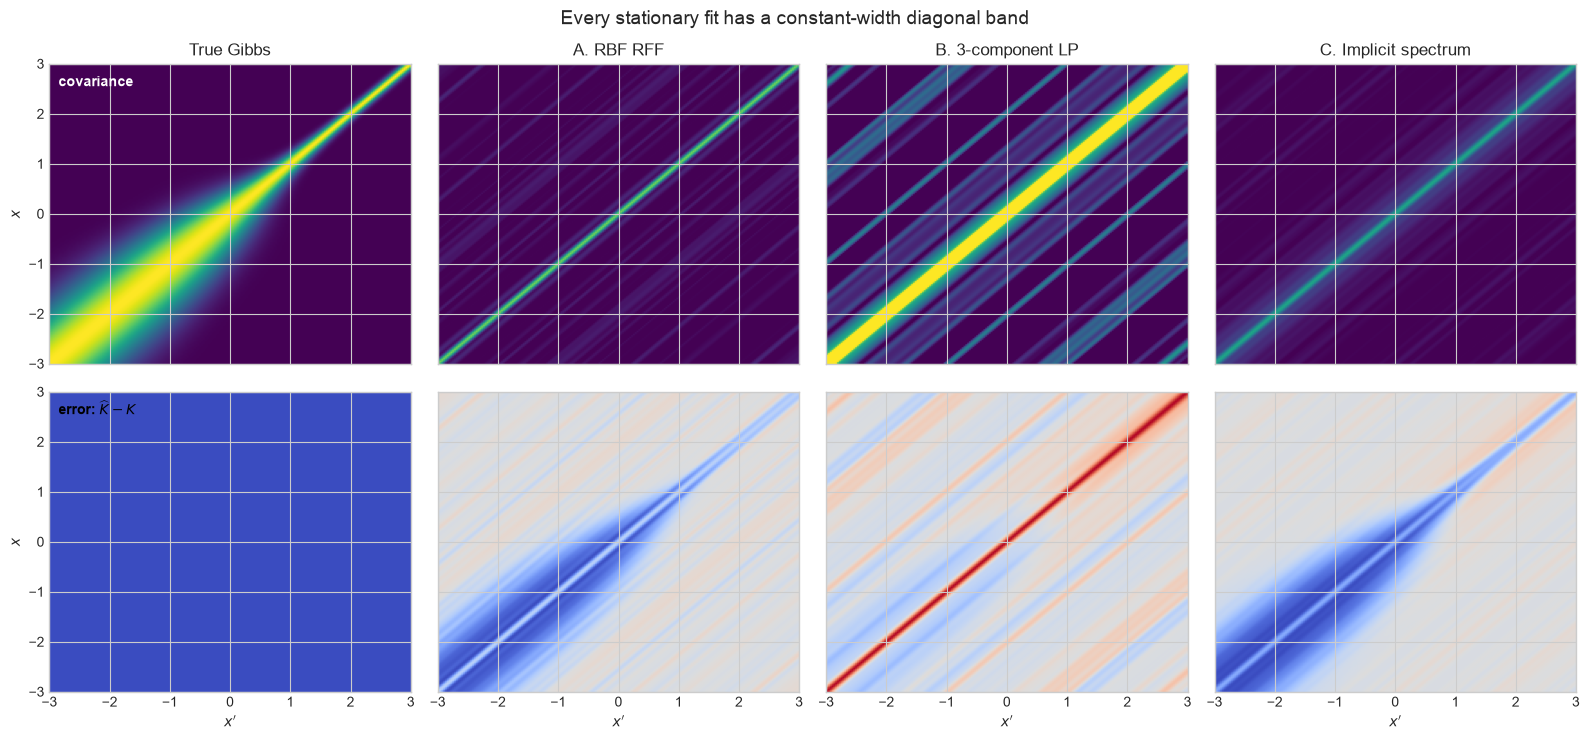

In [61]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5), sharex=True, sharey=True)
all_covariances = {"True Gibbs": K, **learned_covariances}

for column, (name, covariance) in enumerate(all_covariances.items()):
    axes[0, column].imshow(
        covariance, origin="lower", extent=[x.min(), x.max(), x.min(), x.max()],
        cmap="viridis", vmin=0.0, vmax=signal_std**2, aspect="auto",
    )
    axes[0, column].set_title(name)
    error = covariance - K
    limit = np.max(np.abs(error))
    axes[1, column].imshow(
        error, origin="lower", extent=[x.min(), x.max(), x.min(), x.max()],
        cmap="coolwarm", vmin=-limit, vmax=limit, aspect="auto",
    )
    axes[1, column].set_xlabel(r"$x'$")
axes[0, 0].set_ylabel(r"$x$")
axes[1, 0].set_ylabel(r"$x$")
axes[0, 0].text(-2.85, 2.55, "covariance", color="white", weight="bold")
axes[1, 0].text(-2.85, 2.55, r"error: $\widehat K-K$", color="black", weight="bold")
fig.suptitle("Every stationary fit has a constant-width diagonal band", fontsize=14)
fig.tight_layout()
plt.show()

### Where the error comes from

A stationary kernel can learn only one covariance curve as a function of lag. The next plot overlays that learned global curve on the three true local covariance slices. A flexible stationary spectrum may find a better global compromise, but it cannot simultaneously match the slow decay on the left and the rapid decay on the right.

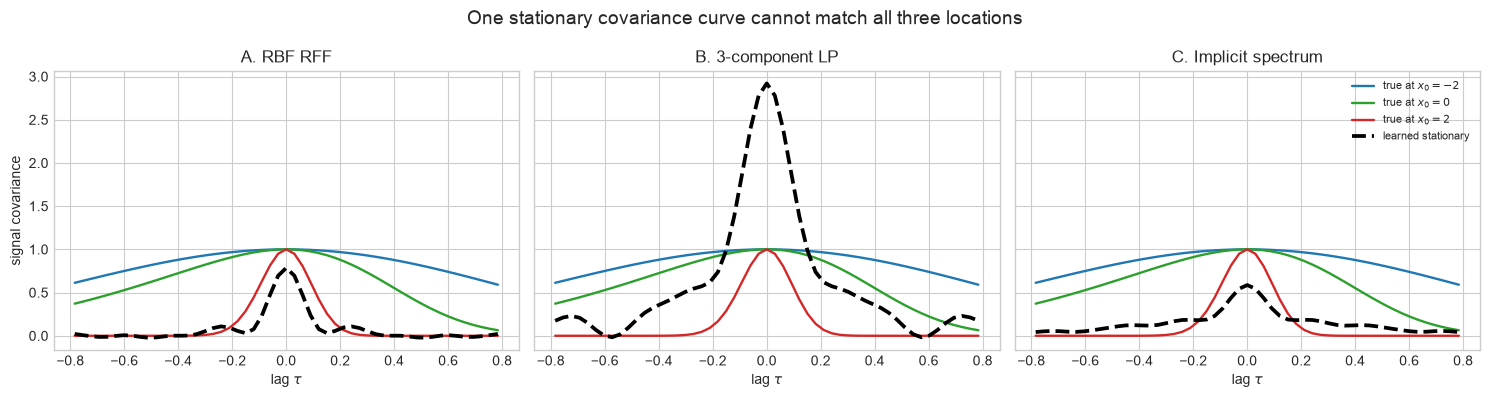

In [62]:
center_index = np.argmin(np.abs(x))
lag_indices = np.arange(-26, 27)
valid_lag_indices = center_index + lag_indices
lag_grid = x[valid_lag_indices] - x[center_index]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, (name, covariance) in zip(axes, learned_covariances.items()):
    for anchor, color in zip(anchors, ["tab:blue", "tab:green", "tab:red"]):
        true_slice = gibbs_kernel(
            np.array([anchor]), anchor + lag_grid, lengthscale_function, signal_std
        ).ravel()
        ax.plot(lag_grid, true_slice, color=color, linewidth=1.7,
                label=rf"true at $x_0={anchor:g}$")
    stationary_slice = covariance[center_index, valid_lag_indices]
    ax.plot(lag_grid, stationary_slice, color="black", linewidth=2.7,
            linestyle="--", label="learned stationary")
    ax.set_title(name)
    ax.set_xlabel(r"lag $\tau$")
axes[0].set_ylabel("signal covariance")
axes[-1].legend(loc="upper right", fontsize=8)
fig.suptitle("One stationary covariance curve cannot match all three locations", fontsize=14)
fig.tight_layout()
plt.show()

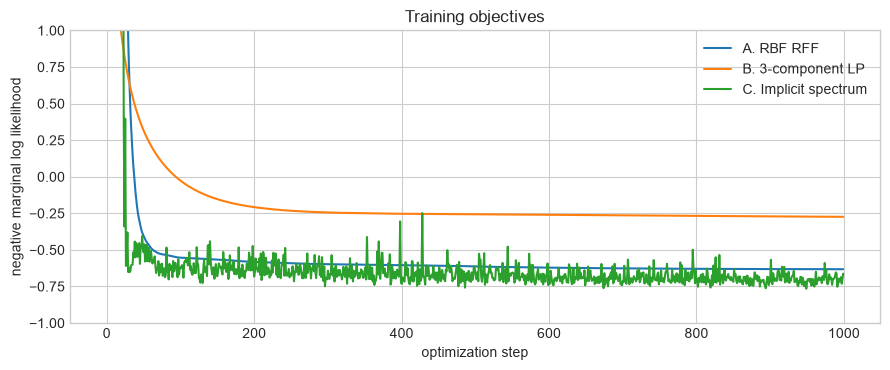

A. RBF parameters: {'mean': -0.06979361921548843, 'lengthscale': 0.06031849980354309, 'outputscale': 0.7855931520462036, 'noise': 0.001443702494725585}
B. Locally periodic mixture parameters:
  mean: -0.0782
  component_means: [0.8054 0.168  1.606 ]
  mixture_weights: [0.051  0.0329 0.9161]
  spectral_variances: [3.37000e-02 1.17872e+01 1.05996e+02]
  outputscale: 2.9199
  noise: 0.0053
C. Implicit frequency RMS: 12.922286987304688


In [63]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(rbf_losses, label="A. RBF RFF")
ax.plot(lp_losses, label="B. 3-component LP")
ax.plot(implicit_history.negative_mll, label="C. Implicit spectrum")
ax.set_ylim(-1, 1)
ax.set(xlabel="optimization step", ylabel="negative marginal log likelihood",
       title="Training objectives")
ax.legend()
fig.tight_layout()
plt.show()

print("A. RBF parameters:", learned_hyperparameters(rbf_model, rbf_likelihood))
print("B. Locally periodic mixture parameters:")
for key, value in learned_spectral_mixture_parameters(lp_model, lp_likelihood).items():
    print(f"  {key}: {np.round(value, 4) if isinstance(value, np.ndarray) else round(value, 4)}")
implicit_kernel = implicit_model.covar_module.base_kernel
print("C. Implicit frequency RMS:",
      float(implicit_kernel.frequency_l2().detach().sqrt().cpu()))

## 8. Non-stationary spectral kernels

There are many papers proposing spectral constructions for non-stationary kernels. We focus on the particular construction developed in **our NeurIPS 2025 paper, _Multi-View-Oriented GPLVM: Expressiveness and Efficiency_**. Although the paper uses the kernel inside a GPLVM, that application is not important here: for now, we study only the underlying kernel. We choose this formulation because its spectral representation is especially convenient and, crucially, Theorem 2 provides a direct random Fourier feature map.

### From one frequency to a pair of frequencies

Ordinary Bochner's theorem represents a stationary kernel using one frequency $\mathbf w$:

$$k(\mathbf x_1,\mathbf x_2)=\int \exp\left(i\mathbf w^\top(\mathbf x_1-\mathbf x_2)\right)p(\mathbf w)\,d\mathbf w.$$

The same frequency multiplies both inputs, so the result can depend only on their difference. The central idea for obtaining non-stationarity is to work instead with a **pair** $(\mathbf w_1,\mathbf w_2)$ drawn jointly from a bivariate spectral object. The two inputs can then interact with different, statistically coupled frequencies.

### Theorem 1: the spectral representation

Theorem 1 of the paper states that a bounded continuous complex-valued kernel $k(\mathbf x_1,\mathbf x_2)$ on $\mathbb R^D$ is the covariance of a mean-square continuous complex-valued random process if and only if it can be written as

$$
\begin{aligned}
k(\mathbf x_1,\mathbf x_2)=\frac14\int &\Big[
e^{i(\mathbf w_1^\top\mathbf x_1-\mathbf w_2^\top\mathbf x_2)}
+e^{i(\mathbf w_2^\top\mathbf x_1-\mathbf w_1^\top\mathbf x_2)}\\
&+e^{i\mathbf w_1^\top(\mathbf x_1-\mathbf x_2)}
+e^{i\mathbf w_2^\top(\mathbf x_1-\mathbf x_2)}
\Big]\,u(d\mathbf w_1,d\mathbf w_2).
\end{aligned}
$$

Here $u$ is a bivariate Lebesgue--Stieltjes measure associated with the spectral construction. A general bivariate measure does **not** necessarily admit a probability density with respect to Lebesgue measure; it may, for example, contain singular or discrete parts. In this notebook we deliberately restrict attention to the absolutely continuous case in which the normalized measure admits a joint probability density $p(\mathbf w_1,\mathbf w_2)$, so that

$$u(d\mathbf w_1,d\mathbf w_2)=p(\mathbf w_1,\mathbf w_2)\,d\mathbf w_1d\mathbf w_2.$$

Under this assumption, the integral can be read as an expectation over jointly distributed frequency pairs $(\mathbf w_1,\mathbf w_2)\sim p$. This density assumption is convenient for sampling and is the case we will use below, but it is an assumption on our construction rather than a property of every possible spectral measure.

### Where does non-stationarity enter?

The first two terms contain

$$\mathbf w_1^\top\mathbf x_1-\mathbf w_2^\top\mathbf x_2,$$

rather than a single frequency multiplying $\mathbf x_1-\mathbf x_2$. When $\mathbf w_1\neq\mathbf w_2$, translating both inputs by the same vector $\mathbf c$ adds $(\mathbf w_1-\mathbf w_2)^\top\mathbf c$ to the phase. The covariance can therefore change under a common translation and can depend on the absolute input locations: it is non-stationary.

The last two terms are ordinary stationary contributions, one from each marginal frequency. Together, the four terms symmetrize the roles of the two inputs and frequencies and lead to the feature representation below. In the special case $\mathbf w_1=\mathbf w_2=\mathbf w$, all four terms coincide and Theorem 1 reduces to the usual Bochner representation. Thus ordinary stationary spectral kernels sit inside this larger family as the diagonal case of the joint spectral distribution.

### Theorem 2: a convenient RFF map

Theorem 2 is the practical reason we use this construction. Draw $L/2$ independent frequency pairs

$$\left\{(\mathbf w_1^{(l)},\mathbf w_2^{(l)})\right\}_{l=1}^{L/2}\overset{\mathrm{i.i.d.}}{\sim}p(\mathbf w_1,\mathbf w_2),$$

and define the $L$-dimensional real feature map. Writing every entry explicitly makes the stacking clear:

$$
\boldsymbol\phi(\mathbf x)=\sqrt{\frac{1}{2L}}
\begin{bmatrix}
\cos((\mathbf w_1^{(1)})^\top\mathbf x)+\cos((\mathbf w_2^{(1)})^\top\mathbf x)\\
\cos((\mathbf w_1^{(2)})^\top\mathbf x)+\cos((\mathbf w_2^{(2)})^\top\mathbf x)\\
\vdots\\
\cos((\mathbf w_1^{(L/2)})^\top\mathbf x)+\cos((\mathbf w_2^{(L/2)})^\top\mathbf x)\\[3pt]
\sin((\mathbf w_1^{(1)})^\top\mathbf x)+\sin((\mathbf w_2^{(1)})^\top\mathbf x)\\
\sin((\mathbf w_1^{(2)})^\top\mathbf x)+\sin((\mathbf w_2^{(2)})^\top\mathbf x)\\
\vdots\\
\sin((\mathbf w_1^{(L/2)})^\top\mathbf x)+\sin((\mathbf w_2^{(L/2)})^\top\mathbf x)
\end{bmatrix}\in\mathbb R^L.
$$

The first $L/2$ coordinates are cosine features and the final $L/2$ coordinates are sine features. Importantly, coordinate $l$ combines the two frequencies from the **same joint draw** $(\mathbf w_1^{(l)},\mathbf w_2^{(l)})$; we are not stacking separate feature vectors for all $\mathbf w_1$ samples and then all $\mathbf w_2$ samples. Equivalently, if

$$\mathbf W_j=[\mathbf w_j^{(1)},\ldots,\mathbf w_j^{(L/2)}]\in\mathbb R^{D\times L/2},\qquad j\in\{1,2\},$$

then each expression such as $\cos(\mathbf W_j^\top\mathbf x)$ denotes an $L/2$-dimensional vector, with cosine applied elementwise. The resulting inner product is an unbiased Monte Carlo estimator:

$$k(\mathbf x_1,\mathbf x_2)\approx\boldsymbol\phi(\mathbf x_1)^\top\boldsymbol\phi(\mathbf x_2).$$

This looks very close to ordinary RFFs, but each feature now combines two jointly drawn frequencies. The cross-products between the $\mathbf w_1$ and $\mathbf w_2$ trigonometric terms generate the non-stationary part of Theorem 1, while the same-frequency products generate its stationary part. We will specify and learn the joint density $p(\mathbf w_1,\mathbf w_2)$ in the next stage.

## 9. Learning paired non-stationary spectral distributions

We now fit four joint spectral models through the feature map in Theorem 2. Every model emits paired frequencies $(w_1,w_2)$, so it can represent covariance that depends separately on $x_1$ and $x_2$. The models differ only in how flexible the joint density $p(w_1,w_2)$ is:

1. One bivariate Gaussian with a diagonal covariance matrix.
2. One bivariate Gaussian with a learned correlation.
3. A marginalized mixture of three correlated bivariate Gaussians.
4. An implicit neural joint spectral distribution.

As before, all kernel parameters are shared across the population of signals and are learned by maximizing their average GP marginal likelihood.

### Differentiable samples from a correlated bivariate Gaussian

For one spectral component, write

$$
\begin{bmatrix}w_1\\w_2\end{bmatrix}
\sim\mathcal N\left(
\begin{bmatrix}\mu_1\\\mu_2\end{bmatrix},
\begin{bmatrix}
\sigma_1^2 & \rho\sigma_1\sigma_2\\
\rho\sigma_1\sigma_2 & \sigma_2^2
\end{bmatrix}
\right).
$$

A direct draw would hide the dependence on the covariance parameters from automatic differentiation. Instead we use the pathwise, or reparameterization, form. Draw parameter-free noise $\epsilon_1,\epsilon_2\overset{\mathrm{i.i.d.}}{\sim}\mathcal N(0,1)$ and set

$$
w_1=\mu_1+\sigma_1\epsilon_1,\qquad
w_2=\mu_2+\sigma_2\left(\rho\epsilon_1+\sqrt{1-\rho^2}\,\epsilon_2\right).
$$

This is a two-dimensional Cholesky reparameterization. The shared $\epsilon_1$ produces $\operatorname{Cov}(w_1,w_2)=\rho\sigma_1\sigma_2$. Every operation is differentiable in $\mu_1,\mu_2,\sigma_1,\sigma_2$, and $\rho$. We parameterize the standard deviations with `softplus` and the correlation as $\rho=0.99\tanh(r)$, which guarantees $\sigma_j>0$ and $|\rho|<1$. For the independent model we simply fix $\rho=0$, giving the diagonal covariance $\operatorname{diag}(\sigma_1^2,\sigma_2^2)$.

In [64]:
from train_paired_spectral_gp import (
    PairedGaussianRFFKernel,
    PairedImplicitRFFKernel,
    build_paired_spectral_gp,
    mean_negative_log_likelihood as paired_mean_negative_log_likelihood,
    train_paired_spectral_gp,
)

num_paired_frequencies = 240

### Model 1: one independent bivariate Gaussian

The joint density factorizes as $p(w_1,w_2)=p_1(w_1)p_2(w_2)$. The two marginal means and variances can differ, so paired frequencies need not be equal and the induced kernel can still be non-stationary. What this model cannot express is direct statistical coupling between the two frequencies.

In [76]:
independent_kernel = PairedGaussianRFFKernel(
    initial_means=torch.tensor([[0.0, 0.0]]),
    initial_stds=torch.tensor([[2.0, 8.0]]),
    num_pairs_per_component=num_paired_frequencies,
    correlated=False,
    seed=seed + 201,
)
independent_model, independent_likelihood = build_paired_spectral_gp(
    train_x_tensor, fit_curves_tensor, independent_kernel,
    initial_outputscale=1.0, initial_noise=noise_std**2,
)
independent_history = train_paired_spectral_gp(
    independent_model, independent_likelihood, train_x_tensor, fit_curves_tensor,
    num_steps=1000, learning_rate=0.015, print_every=100,
)

step    1/1000 | NLL=3.1846 | noise=0.00091
step  100/1000 | NLL=-0.1728 | noise=0.00238
step  200/1000 | NLL=-0.4687 | noise=0.00327
step  300/1000 | NLL=-0.5442 | noise=0.00361
step  400/1000 | NLL=-0.5768 | noise=0.00359
step  500/1000 | NLL=-0.6041 | noise=0.00339
step  600/1000 | NLL=-0.6274 | noise=0.00310
step  700/1000 | NLL=-0.6509 | noise=0.00279
step  800/1000 | NLL=-0.6696 | noise=0.00252
step  900/1000 | NLL=-0.6913 | noise=0.00227
step 1000/1000 | NLL=-0.7045 | noise=0.00206


### Model 2: one correlated bivariate Gaussian

This model learns the off-diagonal covariance through $\rho$. Positive correlation encourages $w_1$ and $w_2$ to move together while still allowing them to differ. The same fixed base-noise samples are transformed at every optimization step, giving a deterministic Monte Carlo objective with gradients through the Cholesky reparameterization above.

In [77]:
correlated_kernel = PairedGaussianRFFKernel(
    initial_means=torch.tensor([[0.0, 0.0]]),
    initial_stds=torch.tensor([[2.0, 8.0]]),
    num_pairs_per_component=num_paired_frequencies,
    correlated=True,
    initial_correlations=torch.tensor([0.7]),
    seed=seed + 202,
)
correlated_model, correlated_likelihood = build_paired_spectral_gp(
    train_x_tensor, fit_curves_tensor, correlated_kernel,
    initial_outputscale=1.0, initial_noise=noise_std**2,
)
correlated_history = train_paired_spectral_gp(
    correlated_model, correlated_likelihood, train_x_tensor, fit_curves_tensor,
    num_steps=1000, learning_rate=0.015, print_every=100,
)

step    1/1000 | NLL=5.3402 | noise=0.00091
step  100/1000 | NLL=0.1983 | noise=0.00243
step  200/1000 | NLL=-0.2695 | noise=0.00348
step  300/1000 | NLL=-0.3868 | noise=0.00411
step  400/1000 | NLL=-0.4463 | noise=0.00439
step  500/1000 | NLL=-0.4823 | noise=0.00437
step  600/1000 | NLL=-0.5087 | noise=0.00417
step  700/1000 | NLL=-0.5374 | noise=0.00388
step  800/1000 | NLL=-0.5609 | noise=0.00353
step  900/1000 | NLL=-0.5868 | noise=0.00320
step 1000/1000 | NLL=-0.6118 | noise=0.00287


### Model 3: a marginalized mixture of correlated Gaussians

Let $p_q(w_1,w_2)$ be three correlated bivariate Gaussian densities centered at different frequencies. We use

$$p(w_1,w_2)=\sum_{q=1}^{3}\alpha_q p_q(w_1,w_2),\qquad \alpha_q=\operatorname{softmax}(a)_q.$$

We do **not** sample $q$. For every component we draw continuous Gaussian base noise, form its Theorem-2 feature block $\boldsymbol\phi_q(x)$, and concatenate

$$\boldsymbol\phi(x)=\left[\sqrt{\alpha_1}\boldsymbol\phi_1(x);\sqrt{\alpha_2}\boldsymbol\phi_2(x);\sqrt{\alpha_3}\boldsymbol\phi_3(x)\right].$$

Its inner product is $\sum_q\alpha_q\boldsymbol\phi_q(x_1)^\top\boldsymbol\phi_q(x_2)$, the analytically marginalized mixture kernel. The softmax weights, component means, variances, and correlations are all differentiable; no Gumbel--Softmax is involved.

In [78]:
mixture_kernel = PairedGaussianRFFKernel(
    initial_means=torch.tensor([[0.0, 0.0], [3.0, 3.0], [9.0, 9.0]]),
    initial_stds=torch.tensor([[1.5, 2.0], [3.0, 4.0], [7.0, 9.0]]),
    num_pairs_per_component=num_paired_frequencies // 3,
    correlated=True,
    initial_correlations=torch.tensor([0.7, 0.7, 0.7]),
    initial_weights=torch.full((3,), 1.0 / 3.0),
    seed=seed + 203,
)
mixture_model, mixture_likelihood = build_paired_spectral_gp(
    train_x_tensor, fit_curves_tensor, mixture_kernel,
    initial_outputscale=1.0, initial_noise=noise_std**2,
)
mixture_history = train_paired_spectral_gp(
    mixture_model, mixture_likelihood, train_x_tensor, fit_curves_tensor,
    num_steps=1000, learning_rate=0.012, print_every=100,
)

step    1/1000 | NLL=2.0301 | noise=0.00091
step  100/1000 | NLL=-0.2194 | noise=0.00208
step  200/1000 | NLL=-0.4708 | noise=0.00283
step  300/1000 | NLL=-0.5451 | noise=0.00314
step  400/1000 | NLL=-0.5831 | noise=0.00315
step  500/1000 | NLL=-0.6186 | noise=0.00297
step  600/1000 | NLL=-0.6404 | noise=0.00273
step  700/1000 | NLL=-0.6650 | noise=0.00248
step  800/1000 | NLL=-0.6864 | noise=0.00225
step  900/1000 | NLL=-0.7075 | noise=0.00204
step 1000/1000 | NLL=-0.7240 | noise=0.00185


### Model 4: an implicit neural joint spectral distribution

Finally, a neural generator maps $\mathbf z\sim\mathcal N(\mathbf0,I)$ directly to a pair,

$$\begin{bmatrix}w_1\\w_2\end{bmatrix}=g_\theta(\mathbf z).$$

The generator can represent nonlinear dependence and non-Gaussian, multimodal joint shapes without requiring us to evaluate $p(w_1,w_2)$. The samples are differentiable because the randomness resides in the parameter-free input $\mathbf z$, while the sampled frequencies are deterministic differentiable functions of $\theta$. A small squared-frequency penalty discourages unnecessarily extreme frequencies.

In [87]:
paired_implicit_kernel = PairedImplicitRFFKernel(
    noise_dimension=8, num_pairs=num_paired_frequencies,
    hidden_features=(64, 64), initial_frequency_scale=5.0, seed=seed + 204,
)
paired_implicit_model, paired_implicit_likelihood = build_paired_spectral_gp(
    train_x_tensor, fit_curves_tensor, paired_implicit_kernel,
    initial_outputscale=1.0, initial_noise=noise_std**2,
)
paired_implicit_history = train_paired_spectral_gp(
    paired_implicit_model, paired_implicit_likelihood,
    train_x_tensor, fit_curves_tensor,
    num_steps=1000, learning_rate=0.004, frequency_penalty_weight=1e-5,
    print_every=100,
)

step    1/1000 | NLL=220.9883 | noise=0.00090
step  100/1000 | NLL=-0.7471 | noise=0.00099
step  200/1000 | NLL=-0.7594 | noise=0.00099
step  300/1000 | NLL=-0.7641 | noise=0.00100
step  400/1000 | NLL=-0.7665 | noise=0.00101
step  500/1000 | NLL=-0.7680 | noise=0.00102
step  600/1000 | NLL=-0.6951 | noise=0.00103
step  700/1000 | NLL=-0.7730 | noise=0.00104
step  800/1000 | NLL=-0.7783 | noise=0.00104
step  900/1000 | NLL=-0.7801 | noise=0.00103
step 1000/1000 | NLL=-0.7820 | noise=0.00103


### Compare the four non-stationary models

We use the same metrics as in the stationary experiment. The covariance errors exclude observation noise, while held-out NLL includes the learned likelihood noise.

In [88]:
paired_models = {
    "1. Independent Gaussian": (independent_model, independent_likelihood),
    "2. Correlated Gaussian": (correlated_model, correlated_likelihood),
    "3. Correlated Gaussian mixture": (mixture_model, mixture_likelihood),
    "4. Implicit neural": (paired_implicit_model, paired_implicit_likelihood),
}

paired_covariances = {}
paired_rows = []
for name, (model, likelihood) in paired_models.items():
    covariance = learned_signal_covariance(model, train_x_tensor)
    paired_covariances[name] = covariance
    paired_rows.append({
        "model": name,
        "relative kernel error": relative_frobenius(covariance, K),
        "mean absolute error": np.mean(np.abs(covariance - K)),
        "left-block error": relative_frobenius(covariance[left_block], K[left_block]),
        "right-block error": relative_frobenius(covariance[right_block], K[right_block]),
        "test NLL / observation": paired_mean_negative_log_likelihood(
            model, likelihood, train_x_tensor, test_curves_tensor
        ),
    })
paired_comparison_table = pd.DataFrame(paired_rows).set_index("model")
display(paired_comparison_table.style.format(precision=4).set_caption(
    "Paired non-stationary spectral models"
))

,relative kernel error,mean absolute error,left-block error,right-block error,test NLL / observation
model,,,,,
1. Independent Gaussian,0.5430,0.1207,0.5155,0.8736,-0.7354
2. Correlated Gaussian,0.7391,0.1354,0.7934,0.3119,-0.6270
3. Correlated Gaussian mixture,0.5345,0.1179,0.3744,1.2166,-0.7500
4. Implicit neural,0.6881,0.1305,0.7276,0.5680,-0.7818


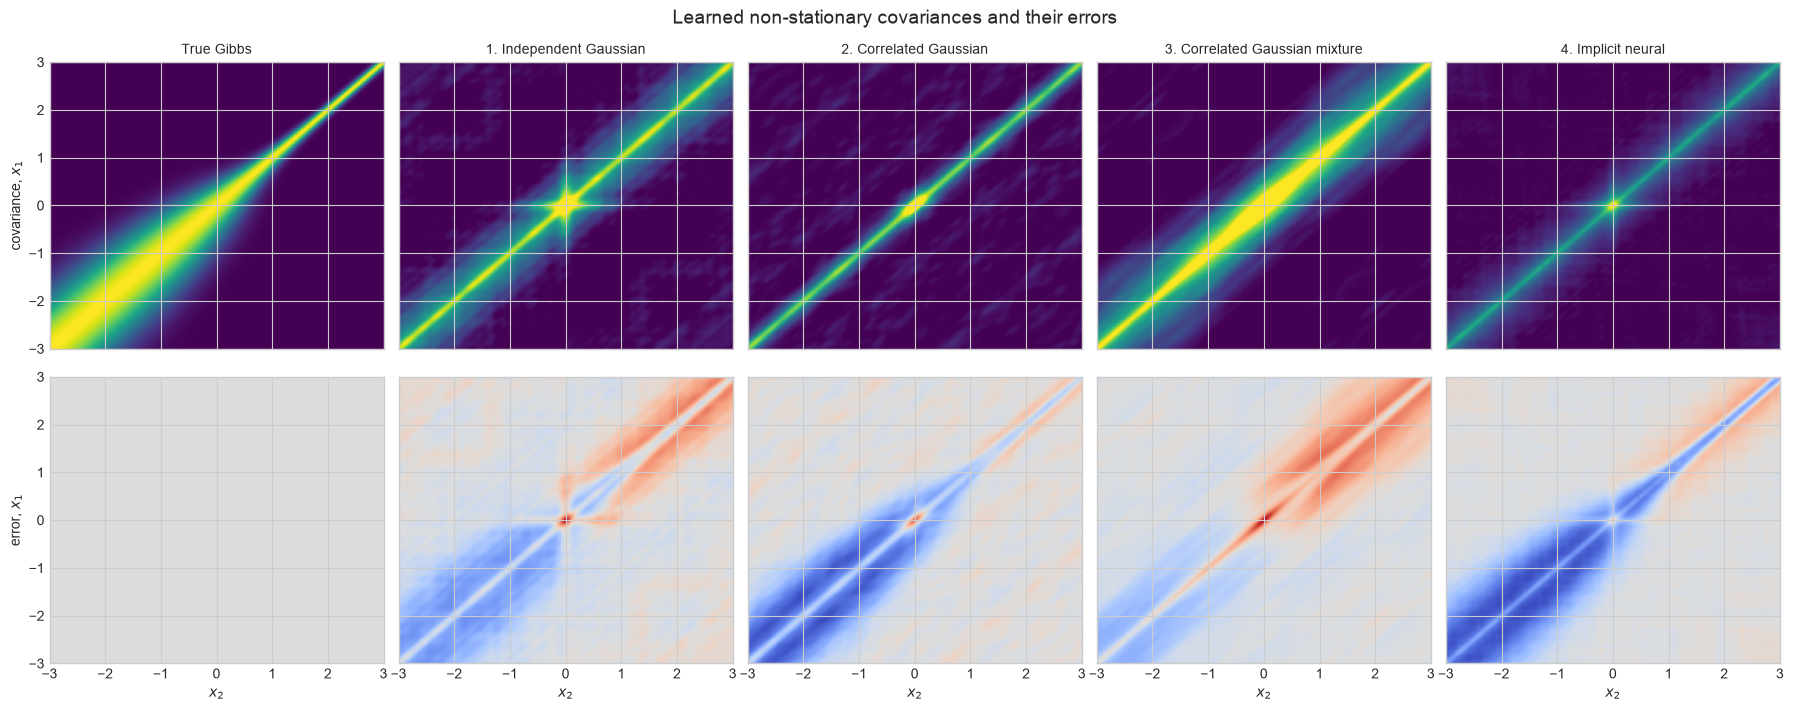

In [89]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7.2), sharex=True, sharey=True)
all_paired_covariances = {"True Gibbs": K, **paired_covariances}
for column, (name, covariance) in enumerate(all_paired_covariances.items()):
    axes[0, column].imshow(
        covariance, origin="lower", extent=[x.min(), x.max(), x.min(), x.max()],
        cmap="viridis", vmin=0.0, vmax=signal_std**2, aspect="auto",
    )
    axes[0, column].set_title(name, fontsize=10)
    error = covariance - K
    limit = max(np.max(np.abs(error)), 1e-8)
    axes[1, column].imshow(
        error, origin="lower", extent=[x.min(), x.max(), x.min(), x.max()],
        cmap="coolwarm", vmin=-limit, vmax=limit, aspect="auto",
    )
    axes[1, column].set_xlabel(r"$x_2$")
axes[0, 0].set_ylabel(r"covariance, $x_1$")
axes[1, 0].set_ylabel(r"error, $x_1$")
fig.suptitle("Learned non-stationary covariances and their errors", fontsize=14)
fig.tight_layout()
plt.show()

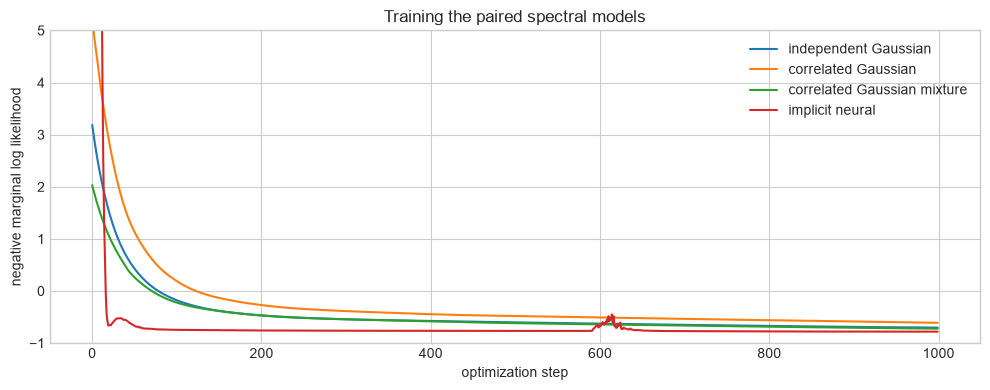

independent:
  means = [[ 0.183 -0.022]]
  stds  = [[ 1.736 11.727]]
  rho   = [0.]
  weights = [1.]
correlated:
  means = [[-0.952 -1.214]]
  stds  = [[ 5.21  11.792]]
  rho   = [0.676]
  weights = [1.]
mixture:
  means = [[ 0.769  0.256]
 [ 4.112  2.71 ]
 [13.131 12.885]]
  stds  = [[ 2.154  1.405]
 [ 3.496  6.181]
 [10.228 12.453]]
  rho   = [0.979 0.752 0.75 ]
  weights = [0.491 0.321 0.187]


In [90]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(independent_history.loss, label="independent Gaussian")
ax.plot(correlated_history.loss, label="correlated Gaussian")
ax.plot(mixture_history.loss, label="correlated Gaussian mixture")
ax.plot(paired_implicit_history.loss, label="implicit neural")
ax.set(xlabel="optimization step", ylabel="negative marginal log likelihood",
       title="Training the paired spectral models")
ax.set_ylim(-1,5)
ax.legend()
fig.tight_layout()
plt.show()

for name, kernel in {
    "independent": independent_kernel,
    "correlated": correlated_kernel,
    "mixture": mixture_kernel,
}.items():
    print(f"{name}:")
    print("  means =", np.round(kernel.means.detach().cpu().numpy(), 3))
    print("  stds  =", np.round(kernel.stds.detach().cpu().numpy(), 3))
    print("  rho   =", np.round(kernel.correlations.detach().cpu().numpy(), 3))
    print("  weights =", np.round(kernel.mixture_weights.detach().cpu().numpy(), 3))

## Takeaway

This dataset has one deliberately isolated source of non-stationarity: its local lengthscale. All signals share the same zero mean, constant marginal variance, and smooth-to-rough transition. RBF, spectral-mixture, and implicit spectral kernels can offer progressively richer **stationary** covariance shapes, but richer spectra alone do not remove the structural error caused by enforcing the same covariance at every location.